# 2026-09-07 | MAUVE seminar poster image options

Reproducible figures following the final poster discussion in
[Seminar Package Advice](https://chatgpt.com/c/6a9d3c52-9460-83ec-be1d-7023ec6a0ae4).
The three requested options are **a MAUVE RGB mosaic**, **a representative galaxy RGB image**,
and **star formation over a grayscale stellar-mass map**. NGC4501 and NGC4654 are the main examples.
The curated mosaic omits NGC4254, NGC4321, and NGC4535; the complete local image inventory retains them.

**Run all cells** with the ICRAR Python environment. All products go into
`20260907_MAUVE_seminar_poster_images/` beside this notebook. Inputs and previous notebooks stay read-only.
The notebook contains its plotting functions and displays compact previews; it does not run the mass/SFR pipelines.

The main outputs are `01_mosaic_curated`, `02_NGC4501_RGB`, and `03_SFR_on_stellar_mass_pair`,
each as a 300-dpi PNG and a one-page PDF. Bonus PNGs include NGC4654, a two-galaxy RGB portrait,
the complete inventory, individual overlays, an RGB/map comparison, and an RGB hero with survey thumbnails.
`00_options_overview.png` is a comparison sheet, not the print master.

In [1]:
from __future__ import annotations
import cv2

from pathlib import Path
import hashlib
import json
import math
import platform
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.lines import Line2D
from PIL import Image as PILImage, ImageOps, ImageDraw, ImageFont
from astropy.io import fits
from astropy import units as u
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from IPython.display import display, Image as DisplayImage

PROJECT_ROOT = Path('/Users/Igniz/Desktop/ICRAR/further')
VRI_ROOT = PROJECT_ROOT.parent / 'v3tk_to_VRI'
DATA_ROOT = PROJECT_ROOT / 'v3tk_v7.6.8'
BANNER_PATH = PROJECT_ROOT.parent / 'MAUVE' / 'mauve_newbanner.png'
OUT = PROJECT_ROOT / '20260907_MAUVE_seminar_poster_images'
OUT.mkdir(exist_ok=True)

HERO_GALAXIES = ('NGC4501', 'NGC4654')
CURATED_GALAXIES = (
    'NGC4501', 'NGC4654', 'NGC4567_8', 'NGC4383',
    'NGC4192', 'NGC4298', 'NGC4380', 'NGC4522',
    'NGC4394', 'NGC4457', 'NGC4419', 'NGC4330',
    'NGC4064', 'NGC4189', 'NGC4402', 'NGC4694',
)
STAGE_9_GALAXIES = (
    'NGC4189', 'NGC4383', 'NGC4567_8',
    'NGC4501', 'NGC4654', 'NGC4522',
    'NGC4064', 'NGC4698', 'NGC4569',
)
PHANGS_EXEMPLARS = {'NGC4254', 'NGC4321', 'NGC4535'}
# Change to 'combined' only if the documented MUSE/Legacy seams are acceptable.
RGB_KIND = 'observed'
SAVE_DPI = 600
PREVIEW_WIDTH = 1000
EW_HA_MIN = 6.0                         # Angstrom, strict >
HALPHA_SIGMA_MAX = 45.0                 # km/s, strict <
SFH_SNR_POSTFIT_MIN = 25.0              # strict >; current stage notebook QC
WCS_TOLERANCE_ARCSEC = 0.05
MASS_LIMITS = (6.5, 9.7)                # log10(M_sun/kpc^2), shared across both galaxies
SFR_LIMITS = (-3.5, -0.5)               # log10(M_sun/yr/kpc^2), shared across both galaxies
SFR_ALPHA = 0.90                       # constant on all selected SF pixels, zero elsewhere
LOGO_CROP = (35, 25, 475, 425)          # original artwork + black padding, no redraw

BG = '#000000'
FG = '#f4f1f4'
MUTED = '#bbb4bd'
ACCENT = '#c390b5'
SFR_CMAP = LinearSegmentedColormap.from_list(
    'mauve_sfr', ['#68248f', '#bf398d', '#f2776b', '#febc72', '#fff1b6'])
MASS_NORM = Normalize(*MASS_LIMITS, clip=True)
SFR_NORM = Normalize(*SFR_LIMITS, clip=True)
mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 12,
    'figure.dpi': 110, 'savefig.dpi': SAVE_DPI,
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'text.color': FG, 'axes.labelcolor': FG,
    'xtick.color': FG, 'ytick.color': FG,
    'axes.edgecolor': MUTED, 'pdf.fonttype': 42,
})
PRODUCTS = []
SOURCE_RECORDS = {}
MAP_QC = []

def source_record(path, full_hash=False):
    path = Path(path).resolve()
    st = path.stat()
    rec = {'path': str(path), 'bytes': st.st_size, 'mtime_ns': st.st_mtime_ns}
    if full_hash:
        with path.open('rb') as stream:
            rec['sha256'] = hashlib.file_digest(stream, 'sha256').hexdigest()
    old = SOURCE_RECORDS.get(str(path), {})
    SOURCE_RECORDS[str(path)] = {**old, **rec}
    return path

def label(g):
    return 'NGC4567 / NGC4568' if g == 'NGC4567_8' else g

def rgb_path(g):
    return VRI_ROOT / f'{g}_{RGB_KIND}_VRI.png'

def load_rgb(g):
    return np.asarray(PILImage.open(source_record(rgb_path(g), full_hash=True)).convert('RGB'))

logo = PILImage.open(source_record(BANNER_PATH, full_hash=True)).convert('RGB').crop(LOGO_CROP)
logo.save(OUT / 'MAUVE_logo_from_existing_banner.png')
available = sorted(p.name.removesuffix(f'_{RGB_KIND}_VRI.png')
                   for p in VRI_ROOT.glob(f'*_{RGB_KIND}_VRI.png')
                   if p.name.startswith(('NGC', 'IC')))
assert set(HERO_GALAXIES + CURATED_GALAXIES + STAGE_9_GALAXIES) <= set(available)
assert not set(CURATED_GALAXIES) & PHANGS_EXEMPLARS
assert len(CURATED_GALAXIES) == len(set(CURATED_GALAXIES))
rgb_inventory = pd.DataFrame([
    {'field': g, 'named_components': 2 if g == 'NGC4567_8' else 1,
     'width': PILImage.open(rgb_path(g)).width, 'height': PILImage.open(rgb_path(g)).height,
     'curated': g in CURATED_GALAXIES, 'path': str(rgb_path(g))} for g in available
])
display(rgb_inventory)
print(f'{len(available)} local RGB fields; {rgb_inventory.named_components.sum()} named galaxy components.')
print('This is the local image inventory, not a claim about the science-ready sample.')


,field,named_components,width,height,curated,path
0,IC3392,1,437,438,False,/Users/Igniz/Desktop/ICRAR/v3tk_to_VRI/IC3392_...
1,NGC4064,1,566,665,True,/Users/Igniz/Desktop/ICRAR/v3tk_to_VRI/NGC4064...
2,NGC4189,1,598,319,True,/Users/Igniz/Desktop/ICRAR/v3tk_to_VRI/NGC4189...
3,NGC4192,1,1092,1629,True,/Users/Igniz/Desktop/ICRAR/v3tk_to_VRI/NGC4192...
4,NGC4222,1,890,748,False,/Users/Igniz/Desktop/ICRAR/v3tk_to_VRI/NGC4222...
5,NGC4254,1,1012,1190,False,/Users/Igniz/Desktop/ICRAR/v3tk_to_VRI/NGC4254...
6,NGC4293,1,923,532,False,/Users/Igniz/Desktop/ICRAR/v3tk_to_VRI/NGC4293...
7,NGC4294,1,567,663,False,/Users/Igniz/Desktop/ICRAR/v3tk_to_VRI/NGC4294...
8,NGC4298,1,1042,995,True,/Users/Igniz/Desktop/ICRAR/v3tk_to_VRI/NGC4298...
9,NGC4302,1,322,1420,False,/Users/Igniz/Desktop/ICRAR/v3tk_to_VRI/NGC4302...


35 local RGB fields; 36 named galaxy components.
This is the local image inventory, not a claim about the science-ready sample.


## Image provenance and display choices

The RGB panels reuse `v3tk_to_VRI/*_observed_VRI.png`: **I = red, R = green, V = blue**,
with the original Lupton/asinh stretch unchanged. The source renderer flips the FITS array vertically for PNG storage;
the notebook displays PNGs with `origin="upper"` and FITS maps with `origin="lower"`.
These are MUSE-derived VRI display composites. As documented in `v3tk_to_VRI/README.md`, the renderer also
uses a low-pass Legacy baseline outside the footprint for its edge adjustment; it does not copy Legacy pixels
underneath the footprint. This existing processing is retained, including visible edge bands.

The all-field product includes 35 fields / 36 named galaxy components in the current local snapshot.
NGC4567/4568 remain together; there is no duplication to fill a 6-by-6 grid. The 4-by-4 curated image is a
visual selection, not a complete or statistically representative sample. RGB tiles are resized with their aspect
ratios and full fields preserved; angular sizes differ between tiles. No galaxy is rotated, mirrored, inpainted,
or assigned synthetic structure. The existing MAUVE artwork is cropped from `MAUVE/mauve_newbanner.png`.

In [2]:
def image_axis(fig, rect, arr, title=None, origin='upper'):
    ax = fig.add_axes(rect)
    ax.imshow(arr, origin=origin, interpolation='nearest', aspect='equal')
    ax.set_axis_off()
    ax.patch.set_alpha(0.0)
    if title:
        ax.text(.025, .975, title, transform=ax.transAxes, va='top', ha='left',
                fontsize=13, weight='medium', color=FG,
                bbox={'facecolor': BG, 'alpha': .72, 'pad': 4, 'edgecolor': 'none'})
    return ax

def branding(fig, title, subtitle, footer):
    w, h = fig.get_size_inches()
    logo_height = .106
    logo_width = logo_height * h / w * (logo.width / logo.height)
    image_axis(fig, [.032, .877, logo_width, logo_height], logo)
    x = .032 + logo_width + .018
    fig.text(x, .954, 'MAUVE-MUSE', fontsize=13, color=ACCENT, weight='bold', va='top')
    fig.text(x, .922, title, fontsize=24, weight='medium', va='top')
    fig.text(x, .883, subtitle, fontsize=11, color=MUTED, va='top')
    fig.add_artist(Line2D([.033, .967], [.850, .850], transform=fig.transFigure,
                          color=ACCENT, linewidth=.65, alpha=.55))
    fig.text(.035, .026, footer, fontsize=9, color=MUTED, va='bottom')

def save_figure(fig, stem, description, galaxies, pdf=False):
    png = OUT / f'{stem}.png'
    fig.savefig(png, dpi=SAVE_DPI, facecolor=BG)
    files = [png.name]
    if pdf:
        pdf_path = OUT / f'{stem}.pdf'
        fig.savefig(pdf_path, dpi=SAVE_DPI, facecolor=BG,
                    metadata={'Title': description, 'Author': 'Rongjun Huang / MAUVE',
                              'Subject': 'MAUVE seminar poster image options, 2026-09-07'})
        files.append(pdf_path.name)
    PRODUCTS.append({'stem': stem, 'description': description, 'galaxies': list(galaxies),
                     'files': files, 'pixels': list(PILImage.open(png).size)})
    plt.close(fig)
    import io
    with PILImage.open(png) as im:
        preview = im.copy()
        preview.thumbnail((PREVIEW_WIDTH, PREVIEW_WIDTH))
        b = io.BytesIO()
        preview.save(b, format='PNG')
    display(DisplayImage(data=b.getvalue()))

from dataclasses import dataclass
import random

@dataclass(frozen=True)
class Rect:
    x: int
    y: int
    w: int
    h: int
    @property
    def right(self) -> int: return self.x + self.w
    @property
    def bottom(self) -> int: return self.y + self.h

def _intersects(a: Rect, b: Rect) -> bool: return not (a.right <= b.x or b.right <= a.x or a.bottom <= b.y or b.bottom <= a.y)
def _contains(outer: Rect, inner: Rect) -> bool: return inner.x >= outer.x and inner.y >= outer.y and inner.right <= outer.right and inner.bottom <= outer.bottom
def _split_free_rect(free: Rect, used: Rect) -> list[Rect]:
    if not _intersects(free, used): return [free]
    pieces = []
    if used.x > free.x: pieces.append(Rect(free.x, free.y, used.x - free.x, free.h))
    if used.right < free.right: pieces.append(Rect(used.right, free.y, free.right - used.right, free.h))
    if used.y > free.y: pieces.append(Rect(free.x, free.y, free.w, used.y - free.y))
    if used.bottom < free.bottom: pieces.append(Rect(free.x, used.bottom, free.w, free.bottom - used.bottom))
    return [r for r in pieces if r.w > 0 and r.h > 0]

def _prune_free_rects(free_rects: list[Rect]) -> list[Rect]:
    pruned = []
    for r in free_rects:
        if not any(_contains(other, r) for other in free_rects if r is not other):
            pruned.append(r)
    return pruned

def _choose_free_rect(free_rects: list[Rect], w: int, h: int):
    best_node = None
    best_score = None
    for fr in free_rects:
        if w <= fr.w and h <= fr.h:
            leftover_w = fr.w - w
            leftover_h = fr.h - h
            score = (min(leftover_w, leftover_h), max(leftover_w, leftover_h), fr.y, fr.x)
            if best_score is None or score < best_score:
                best_score = score
                best_node = Rect(fr.x, fr.y, w, h)
    return best_node

def pack_maxrects(width, height, sizes):
    indexed = list(enumerate(sizes))
    indexed.sort(key=lambda it: (max(it[1]), it[1][0]*it[1][1]), reverse=True)
    free = [Rect(0, 0, width, height)]
    placements = {}
    for idx, (w, h) in indexed:
        node = _choose_free_rect(free, w, h)
        if node is None: return None
        placements[idx] = (node.x, node.y)
        new_free = []
        for fr in free:
            new_free.extend(_split_free_rect(fr, node))
        free = _prune_free_rects(new_free)
    return placements

def optimize_packing(sizes, W_avail=3906, H_avail=3234, gap=20):
    target_aspect = W_avail / H_avail
    sizes_with_gap = [(w + gap, h + gap) for w, h in sizes]
    best_scale = 0
    best_result = None
    rng = random.Random(42)
    orientations_list = [tuple([False]*len(sizes)), tuple([True]*len(sizes))]
    for _ in range(300):
        orientations_list.append(tuple(rng.choice([False, True]) for _ in range(len(sizes))))
    for orients in set(orientations_list):
        curr_sizes = [(h, w) if rot else (w, h) for (w, h), rot in zip(sizes_with_gap, orients)]
        total_area = sum(w*h for w, h in curr_sizes)
        min_w = int(np.sqrt(total_area * target_aspect))
        for tw in range(min_w, min_w + 500, 20):
            th = int(round(tw / target_aspect))
            res = pack_maxrects(tw, th, curr_sizes)
            if res is not None:
                max_x = max(res[i][0] + curr_sizes[i][0] for i in range(len(sizes)))
                max_y = max(res[i][1] + curr_sizes[i][1] for i in range(len(sizes)))
                scale = min(W_avail / max_x, H_avail / max_y)
                if scale > best_scale:
                    best_scale = scale
                    best_result = (scale, max_x, max_y, orients, curr_sizes, res)
                break
    return best_result

def align_and_crop(g):
    im = PILImage.open(rgb_path(g))
    arr = np.array(im)
    m = np.any(arr > 0, axis=-1).astype(np.uint8)
    cnt = np.concatenate(cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0])
    (cx, cy), (w, h), angle = cv2.minAreaRect(cnt)
    if w < h:
        angle += 90
        w, h = h, w
    im_rot = im.rotate(angle, resample=PILImage.Resampling.BICUBIC, expand=True)
    arr_rot = np.array(im_rot)
    m_rot = np.any(arr_rot > 0, axis=-1)
    ys, xs = np.where(m_rot)
    im_crop = im_rot.crop((xs.min(), ys.min(), xs.max() + 1, ys.max() + 1))
    return im_crop, int(im_crop.width), int(im_crop.height), angle

def compact_mosaic_real_size(galaxies, stem, pdf=False):
    crops = {g: align_and_crop(g) for g in galaxies}
    if set(galaxies) == set(STAGE_9_GALAXIES):
        processed_images = {}
        for g in crops:
            im = crops[g][0]
            if g == 'NGC4383':
                im = im.rotate(270, expand=True)
            elif g == 'NGC4698':
                im = im.rotate(180, expand=True)
            elif g == 'NGC4567_8':
                im = im.rotate(90, expand=True)
            elif g == 'NGC4064':
                im = im.rotate(-90, expand=True)
            elif g == 'NGC4522':
                pass
            processed_images[g] = im
        gap = 20
        pos = {}
        pos['NGC4698'] = (0, 0)
        pos['NGC4569'] = (processed_images['NGC4698'].width + gap, 0)
        pos['NGC4501'] = (0, processed_images['NGC4698'].height + gap)
        pos['NGC4654'] = (pos['NGC4569'][0], processed_images['NGC4654'].height + gap)
        pos['NGC4567_8'] = (0, pos['NGC4501'][1] + processed_images['NGC4501'].height + gap)
        y_row3 = max(pos['NGC4654'][1] + processed_images['NGC4654'].height + gap, 1240)
        pos['NGC4064'] = (pos['NGC4567_8'][0] + processed_images['NGC4567_8'].width + gap, y_row3)
        pos['NGC4522'] = (pos['NGC4064'][0] + processed_images['NGC4064'].width + gap, y_row3)
        pos['NGC4189'] = (pos['NGC4522'][0], pos['NGC4522'][1] + processed_images['NGC4522'].height + gap)
        x_right = max(pos['NGC4522'][0] + processed_images['NGC4522'].width, pos['NGC4189'][0] + processed_images['NGC4189'].width) + gap
        pos['NGC4383'] = (x_right, y_row3)
        mx = max(pos[g][0] + processed_images[g].width for g in galaxies)
        my = max(pos[g][1] + processed_images[g].height for g in galaxies)
        scale = min(3906 / mx, 3234 / my)
    else:
        real_sizes = [(crops[g][1], crops[g][2]) for g in galaxies]
        scale, mx, my, orients, csizes, res = optimize_packing(real_sizes, gap=20)
        pos = {g: res[idx] for idx, g in enumerate(galaxies)}
        processed_images = {g: crops[g][0].rotate(90, expand=True) if orients[idx] else crops[g][0]
                            for idx, g in enumerate(galaxies)}
    
    fig = plt.figure(figsize=(14, 14), facecolor=BG)
    branding(fig, 'A resolved view of Virgo',
             f'{len(galaxies)} representative MAUVE fields in MUSE colour (Compact layout, uniform physical scale)',
             'MUSE VRI composites | Custom compact arrangement | ~100 pc spatial resolution')
    
    left_base = 0.035 + (3906 - mx * scale) / (2 * 4200.0)
    top_base = 0.835 - (3234 - my * scale) / (2 * 4200.0)
    
    for g in galaxies:
        x_px, y_px = pos[g]
        im_crop = processed_images[g]
        w_norm = (im_crop.width * scale) / 4200.0
        h_norm = (im_crop.height * scale) / 4200.0
        x_norm = left_base + (x_px * scale) / 4200.0
        y_norm = top_base - ((y_px + im_crop.height) * scale) / 4200.0
        
        ax = fig.add_axes([x_norm, y_norm, w_norm, h_norm])
        ax.imshow(im_crop, origin='upper', aspect='equal')
        ax.set_axis_off()
        ax.text(.035, .94, label(g), transform=ax.transAxes, va='top', ha='left',
                fontsize=11, weight='bold', color='yellow')

    kpc_5_norm = (5000.0 / 16.0 * scale) / 4200.0
    bar_x = 0.965 - kpc_5_norm - 0.015
    bar_y = 0.075 + 0.014
    fig.add_artist(Line2D([bar_x, bar_x + kpc_5_norm], [bar_y, bar_y],
                          transform=fig.transFigure, color=FG, linewidth=2.5))
    fig.text(bar_x + kpc_5_norm/2, bar_y + 0.006, "5 kpc (~1')",
             ha='center', va='bottom', fontsize=10, color=FG)

    save_figure(fig, stem, 'MAUVE RGB mosaic (compact layout, uniform physical scale)', galaxies, pdf=pdf)

def compact_mosaic_equal_area(galaxies, stem, pdf=False):
    crops = {g: align_and_crop(g) for g in galaxies}
    target_area = 550000
    equal_sizes = []
    for g in galaxies:
        w_orig, h_orig = crops[g][1], crops[g][2]
        aspect = w_orig / h_orig
        w_eq = int(round(np.sqrt(target_area * aspect)))
        h_eq = int(round(np.sqrt(target_area / aspect)))
        equal_sizes.append((w_eq, h_eq))

    scale, mx, my, orients, csizes, res = optimize_packing(equal_sizes, gap=20)
    fig = plt.figure(figsize=(14, 14), facecolor=BG)
    branding(fig, 'A resolved view of Virgo',
             f'{len(galaxies)} MAUVE fields across environmental stages (Compact equal-area mosaic)',
             'MUSE VRI composites | Continuous alignment & MaxRects packing | Equal panel area, independent display scales')

    left_base = 0.035 + (3906 - mx * scale) / (2 * 4200.0)
    top_base = 0.835 - (3234 - my * scale) / (2 * 4200.0)

    for idx, g in enumerate(galaxies):
        rot_90 = orients[idx]
        x_px, y_px = res[idx]
        im_crop = crops[g][0]
        if rot_90:
            im_crop = im_crop.rotate(90, expand=True)
        w_target, h_target = equal_sizes[idx]
        if rot_90:
            w_target, h_target = h_target, w_target
        w_norm = (w_target * scale) / 4200.0
        h_norm = (h_target * scale) / 4200.0
        x_norm = left_base + (x_px * scale) / 4200.0
        y_norm = top_base - ((y_px + h_target) * scale) / 4200.0

        ax = fig.add_axes([x_norm, y_norm, w_norm, h_norm])
        ax.imshow(im_crop, origin='upper', aspect='equal')
        ax.set_axis_off()
        ax.text(.035, .94, label(g), transform=ax.transAxes, va='top', ha='left',
                fontsize=11, weight='bold', color=FG,
                bbox={'facecolor': BG, 'alpha': .75, 'pad': 3, 'edgecolor': 'none'})

    save_figure(fig, stem, 'MAUVE RGB mosaic (compact layout, equal panel area)', galaxies, pdf=pdf)

def mosaic(galaxies, stem, ncols=4, pdf=False):
    nrows = math.ceil(len(galaxies) / ncols)
    fig = plt.figure(figsize=(14, 14 if ncols in (3, 4) else 18))
    branding(fig, 'A resolved view of Virgo',
             f'{len(galaxies)} MAUVE fields in MUSE colour',
             'MUSE VRI composites | Independent display scales | Original MAUVE survey artwork')
    left, right, bottom, top = .035, .965, .075, .817
    dx, dy = (right-left)/ncols, (top-bottom)/nrows
    for k, g in enumerate(galaxies):
        r, c = divmod(k, ncols)
        x, y = left+c*dx, top-(r+1)*dy
        image_axis(fig, [x+.005, y+.033, dx-.01, dy-.044], load_rgb(g))
        fig.text(x+dx/2, y+.009, label(g), ha='center', va='bottom', fontsize=11, color=FG)
    save_figure(fig, stem, 'MAUVE RGB mosaic', galaxies, pdf=pdf)

def single_rgb(g, pdf=False):
    fig = plt.figure(figsize=(12, 12))
    branding(fig, label(g), 'A resolved view of a Virgo Cluster galaxy',
             'MUSE-derived VRI colour composite | MAUVE')
    image_axis(fig, [.045, .066, .91, .753], load_rgb(g))
    save_figure(fig, f'02_{g}_RGB', f'{g}: MUSE RGB poster image', [g], pdf=pdf)


## Option 1 | Survey mosaic

The curated 4-by-4 version is the default for a compact seminar advertisement. The full local inventory is a
bonus for larger layouts; its 35 fields are labelled explicitly and include the PHANGS exemplars without making
them the main examples.

The 9-field mosaics utilize an intelligent **2D MaxRects compact packing algorithm** with **continuous pointing rotation** to eliminate empty black corner padding, save space, and maximize galaxy sizes:
1. **Equal panel area**: Each galaxy expands to an equal visual area ($), packed compactly across the canvas with unobtrusive corner name labels.
2. **Relative real size**: Every galaxy shares a **uniform physical scale** (~100 pc spatial resolution), packed to achieve the maximum possible display scale on the poster (~1.6x native size), complete with a calibrated 5 kpc scale bar.


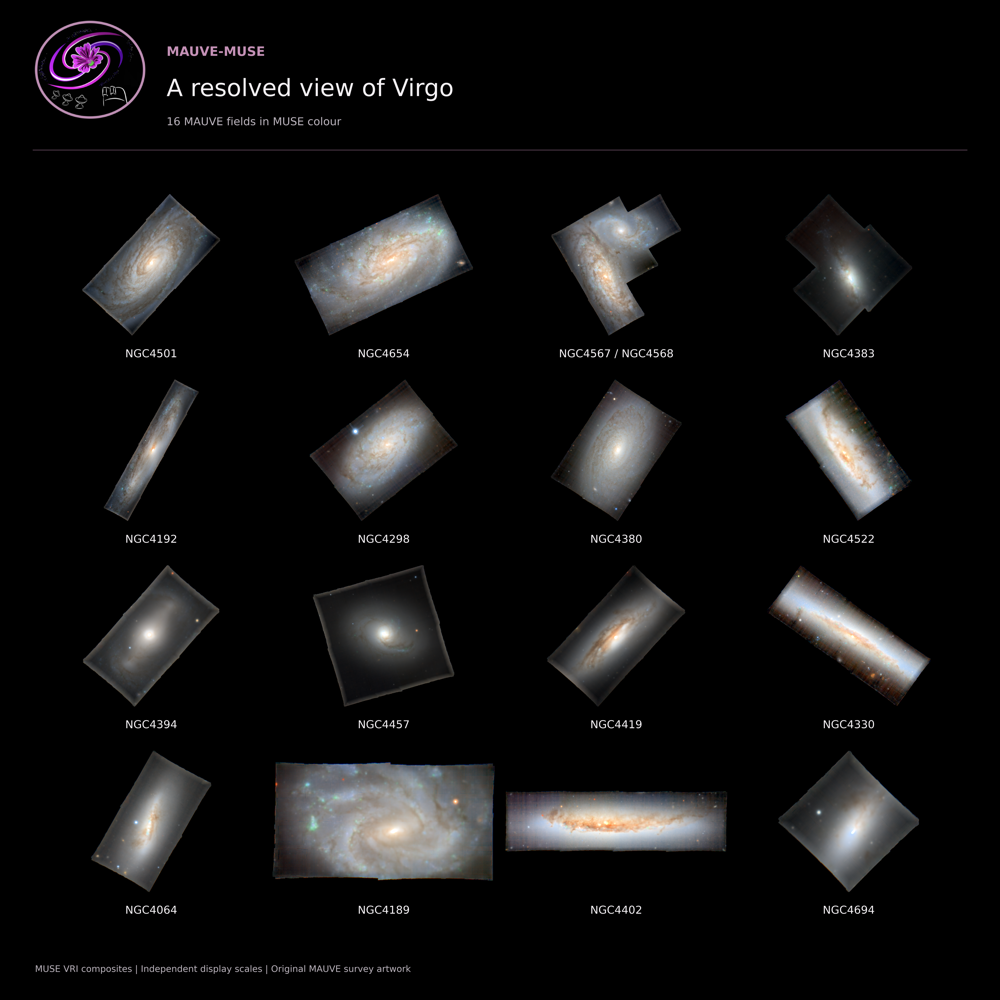

/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (90720000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


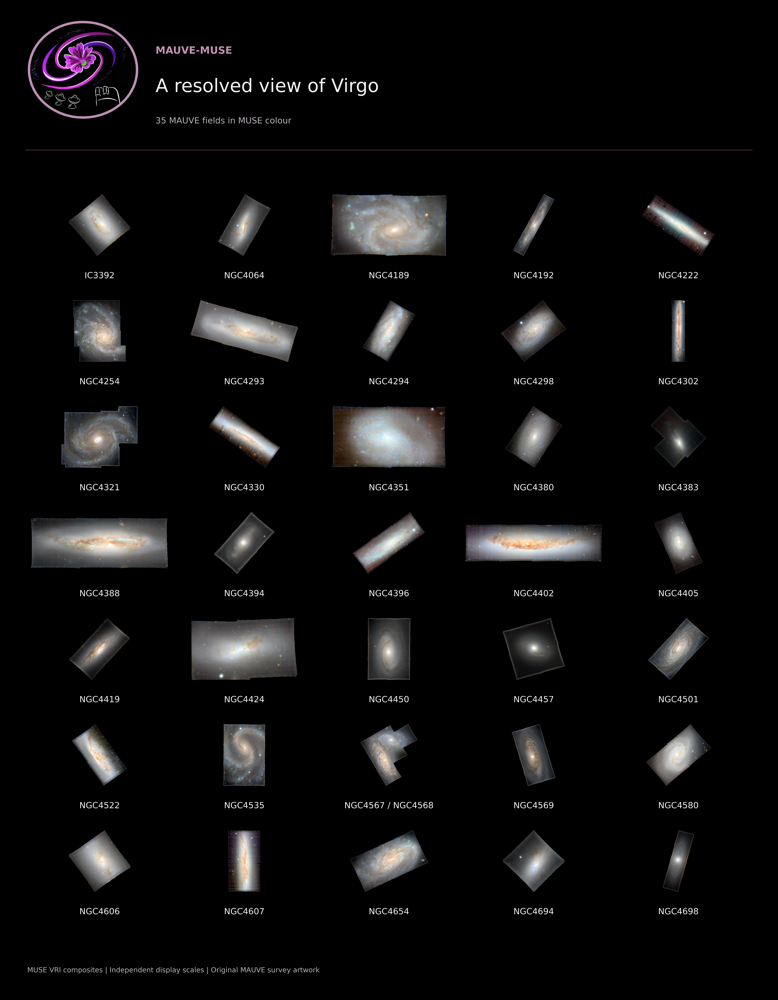

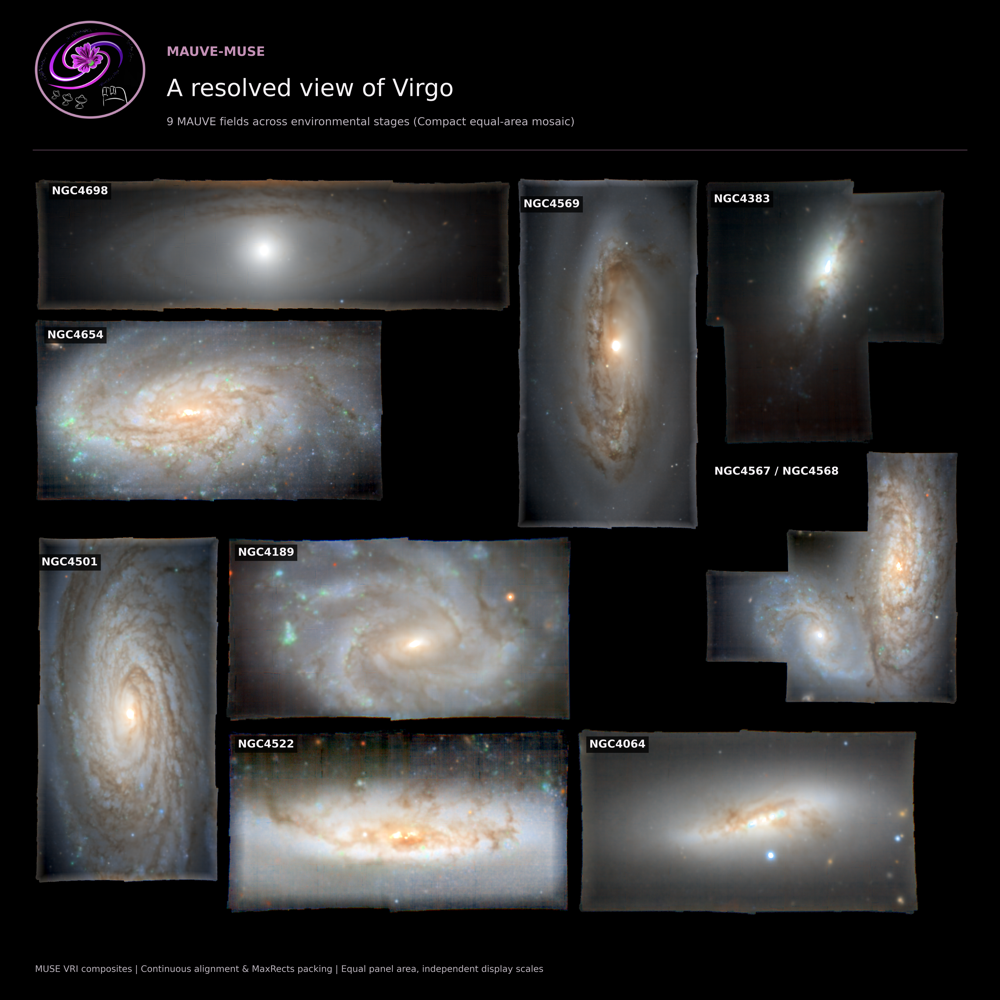

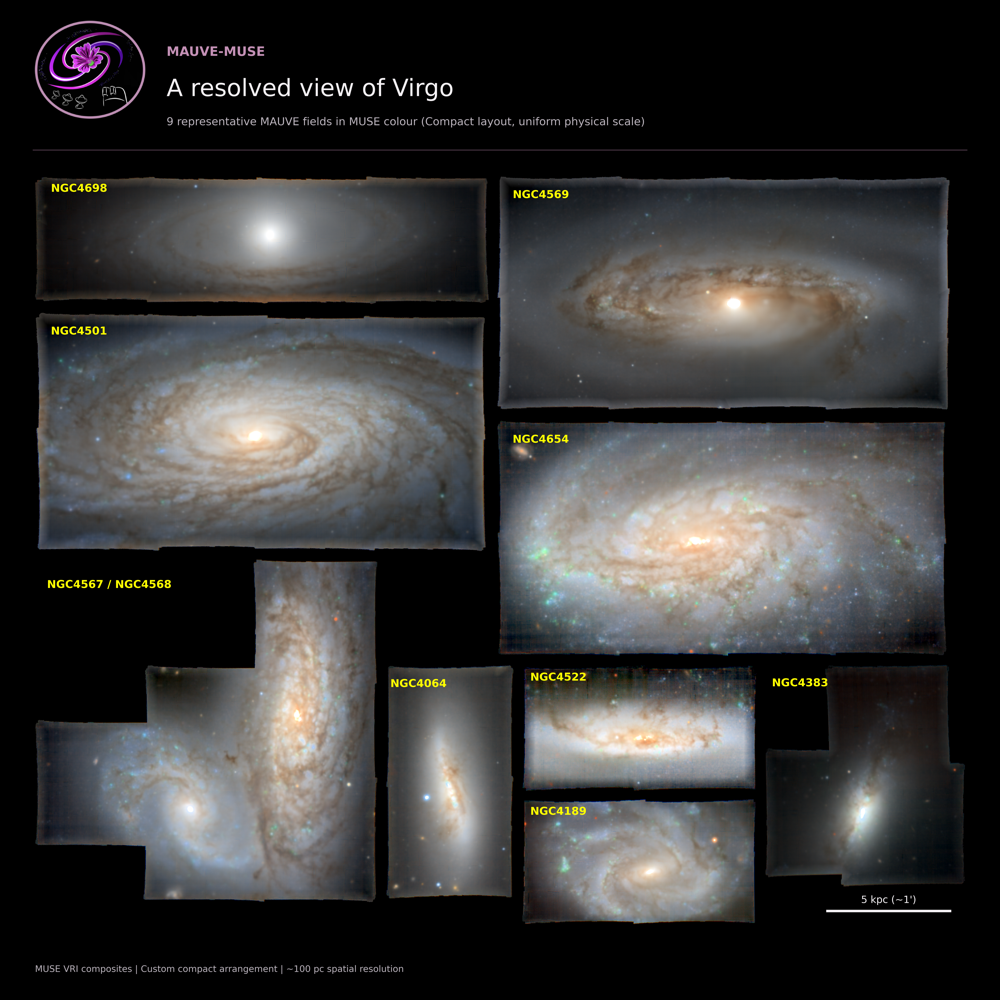

In [3]:
mosaic(CURATED_GALAXIES, '01_mosaic_curated', ncols=4, pdf=True)
mosaic(available, '01_mosaic_all_local_fields', ncols=5)
compact_mosaic_equal_area(STAGE_9_GALAXIES, '01_mosaic_9fields_equal_area', pdf=True)
compact_mosaic_real_size(STAGE_9_GALAXIES, '01_mosaic_9fields_real_size', pdf=True)


## Option 2 | NGC4501 and NGC4654 RGB portraits

Both requested galaxies receive individual images. A paired version gives the organiser a landscape alternative.
The two RGB panels have independent angular sizes and retain the source image stretches.

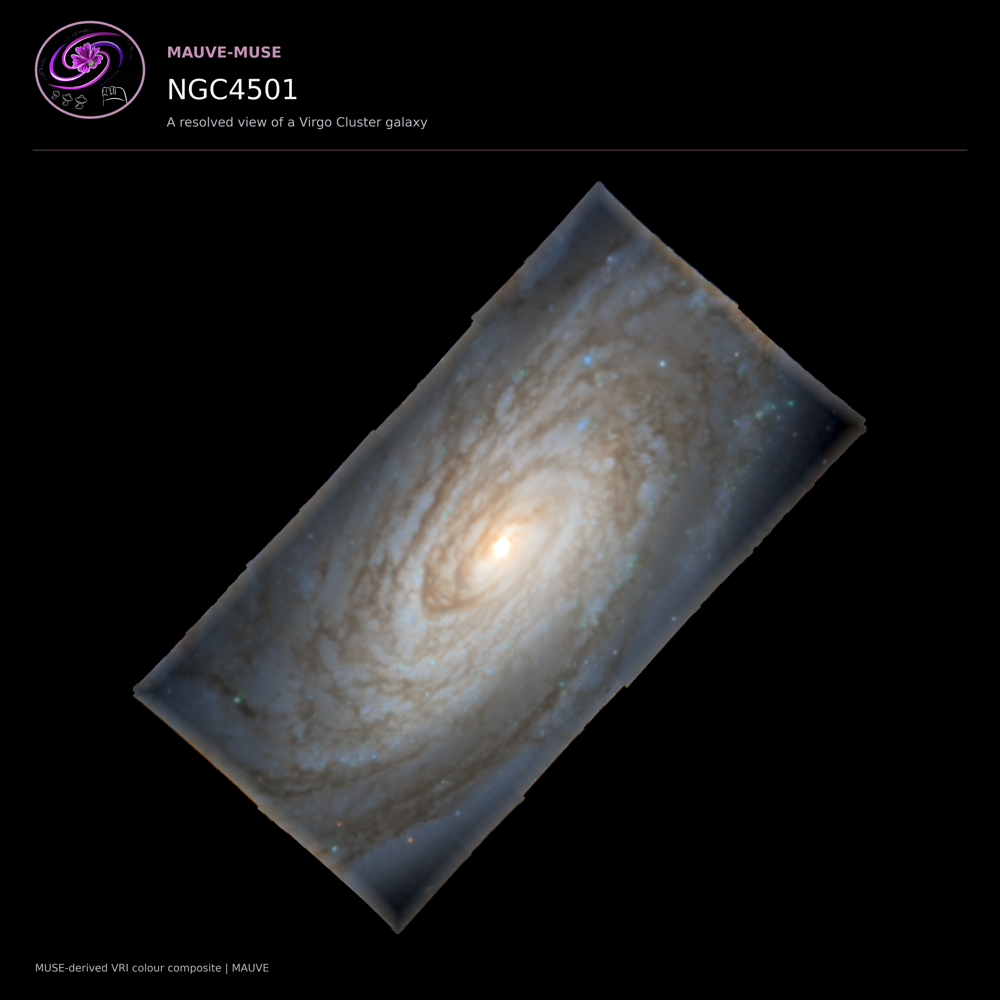

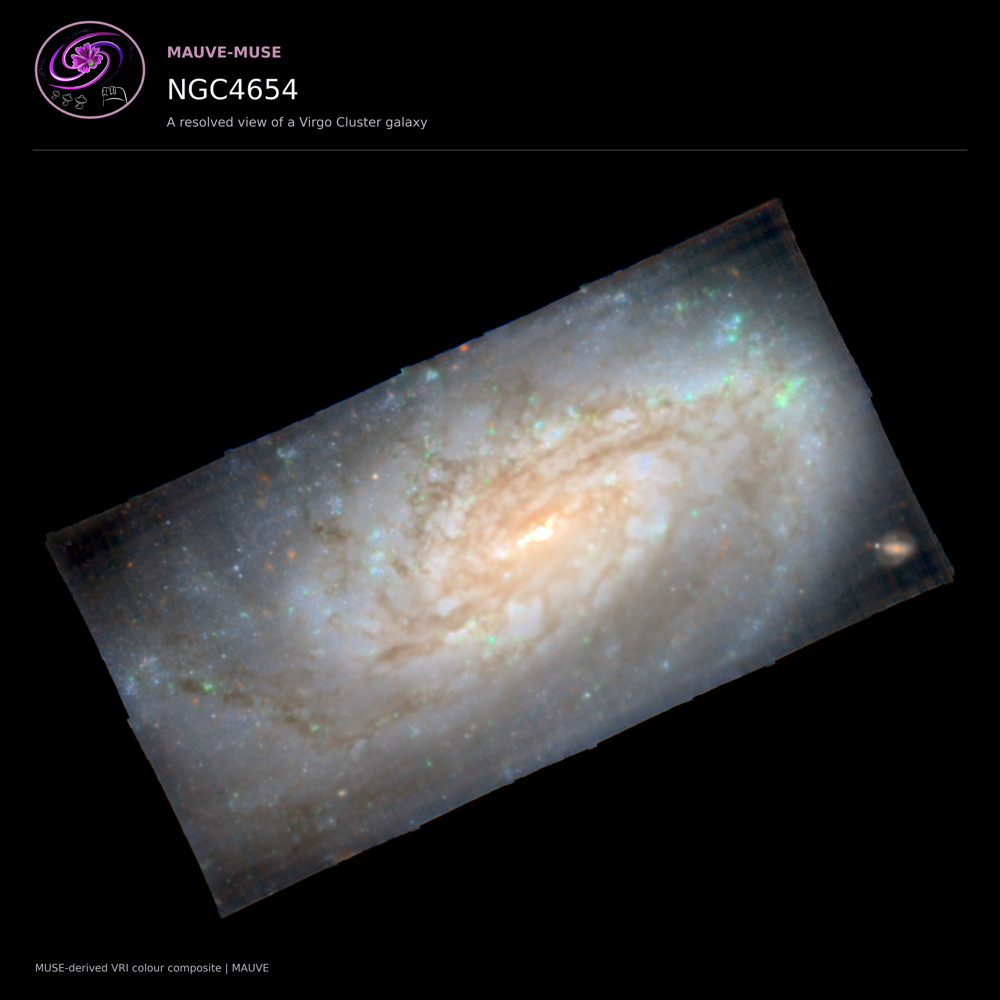

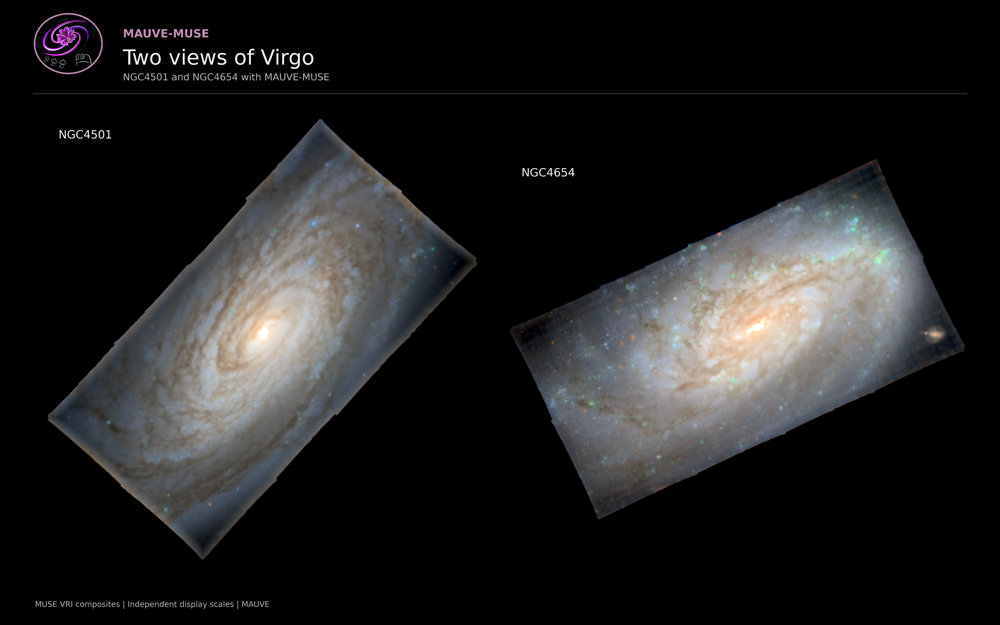

In [4]:
for g in HERO_GALAXIES:
    single_rgb(g, pdf=(g == 'NGC4501'))

fig = plt.figure(figsize=(16, 10))
branding(fig, 'Two views of Virgo', 'NGC4501 and NGC4654 with MAUVE-MUSE',
         'MUSE VRI composites | Independent display scales | MAUVE')
for g, x in zip(HERO_GALAXIES, [.035, .51]):
    image_axis(fig, [x, .105, .455, .705], load_rgb(g), title=label(g))
save_figure(fig, '02_RGB_pair', 'NGC4501 and NGC4654: paired MUSE RGB images', HERO_GALAXIES)

## Option 3 | Star formation over stellar mass

The grayscale background is `LOGMASS_SURFACE_DENSITY` in $\log_{10}(M_\odot\,\mathrm{kpc}^{-2})$.
The coloured layer is `LOGSFR_SURFACE_DENSITY_HII` in
$\log_{10}(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$; the FITS `COMMENT` gives that meaning even
though its `BUNIT` is `1`. No additional inclination or area correction is applied to either stored map.

We use the live selection logic inspected in
`20260904_check_combined_SF_fraction_categories_by_stage_SNR_postfit.ipynb`:
unmasked pixels, finite mass and gas bins, **SFH post-fit S/N > 25**, finite H II SFR,
**proxy EW(H$\alpha$) > 6 Angstrom**, and
**$0 < \sigma_{\mathrm{H}\alpha,\mathrm{intr}} < 45$ km/s**, with
$\sigma_{\mathrm{intr}}^2=\sigma_{\mathrm{obs}}^2-\sigma_{\mathrm{corr}}^2$.
The stored H II SFR selection is authoritative: the separate strict BPT class maps are not interchangeable with it.
In these products, the H II branch can include weak non-Balmer lines or a nominal NII-HII point whose uncertainty
crosses the HII/composite boundary; the header records this treatment in `BPTLIMIT`. The QC table reports the
number of selected pixels that are also strict H II in both separate class maps, without imposing a new mask.
Balmer detection thresholds are checked from each product. We do not apply a radial, inclination, or extra percentile selection to these two
illustrative fields. S/N > 25 is a quality choice consistent with the recent stage notebook, not a new SF definition.

The maps must have identical shapes and match in celestial WCS to 0.05 arcsec; no silent trimming or reprojection
is allowed. Shared colour limits are used for both galaxies. Values outside those limits are display-saturated,
not removed. The coloured layer has constant 90% opacity at every selected pixel; its colour key is therefore a
reference before blending with the gray layer. The bonus side-by-side map figure shows the unblended SFR colour
scale for reading values. Invalid or excluded pixels remain absent; dark regions do not establish zero star formation.
No spatial smoothing, interpolation of missing data, or inference about stripping direction is performed.

In [5]:
def first_product(g, patterns):
    for pattern in patterns:
        base = DATA_ROOT / g / pattern.format(g=g)
        for p in (base, Path(str(base) + '.gz')):
            if p.exists():
                return source_record(p)
    raise FileNotFoundError(f'{g}: no product matching {patterns}')

def read_map(path, name):
    with fits.open(path, memmap=True) as hdus:
        hdu = hdus[name]
        arr = np.array(hdu.data, dtype=np.float64, copy=True)
        header = hdu.header.copy()
    rec = SOURCE_RECORDS[str(Path(path).resolve())]
    rec.setdefault('loaded_hdus', {})[name] = {
        'shape': list(arr.shape), 'BUNIT': header.get('BUNIT'),
        'COMMENT': str(header.get('COMMENT', '')),
        'float64_array_sha256': hashlib.sha256(arr.tobytes()).hexdigest(),
        'header_sha256': hashlib.sha256(header.tostring().encode('ascii')).hexdigest(),
    }
    return arr, header

def check_wcs(a, b, shape):
    wa, wb = WCS(a).celestial, WCS(b).celestial
    if not (wa.has_celestial and wb.has_celestial):
        raise ValueError('Celestial WCS required')
    ny, nx = shape
    x = np.array([0, nx-1, 0, nx-1, (nx-1)/2])
    y = np.array([0, 0, ny-1, ny-1, (ny-1)/2])
    separation = wa.pixel_to_world(x, y).separation(wb.pixel_to_world(x, y)).arcsec
    result = float(np.max(separation))
    assert result <= WCS_TOLERANCE_ARCSEC, f'WCS mismatch: {result:.4f} arcsec'
    return result

def load_science(g):
    mass_path = first_product(g, ['{g}_spatial_binning_maps_further.fits'])
    gas_path = first_product(g, ['{g}_gas_bin_maps_further.fits', '{g}_gas_BIN_maps_further.fits'])
    ew_path = first_product(g, ['{g}_proxy_EW_maps_further.fits', '{g}_proxy_EW_maps.fits'])
    sfh_path = first_product(g, ['{g}_sfh_maps.fits'])
    mask_path = first_product(g, ['{g}_mask.fits'])
    specifications = {
        'mass': (mass_path, 'LOGMASS_SURFACE_DENSITY'),
        'mass_bin': (mass_path, 'BINID'), 'gas_bin': (gas_path, 'BIN_ID'),
        'sfr': (gas_path, 'LOGSFR_SURFACE_DENSITY_HII'),
        'sigma_obs': (gas_path, 'HA6562_SIGMA'), 'sigma_corr': (gas_path, 'HA6562_SIGMA_CORR'),
        'ew': (ew_path, 'PROXY_EWHA'), 'snr': (sfh_path, 'SNR_POSTFIT'),
        'nii_bpt': (gas_path, 'NII_BPT'), 'sii_bpt': (gas_path, 'SII_BPT'),
    }
    arrays, headers = {}, {}
    for key, (path, hdu) in specifications.items():
        arrays[key], headers[key] = read_map(path, hdu)
    shape = arrays['mass'].shape
    assert all(a.shape == shape for a in arrays.values()), f'{g}: unequal map shapes'
    max_sep = max(check_wcs(headers['mass'], h, shape) for h in headers.values())
    with fits.open(mask_path, memmap=True) as h:
        flat_mask = np.array(h['MASKFILE'].data['MASK'], dtype=int, copy=True)
    assert flat_mask.size == np.prod(shape)
    SOURCE_RECORDS[str(mask_path)]['mask_array_sha256'] = hashlib.sha256(flat_mask.tobytes()).hexdigest()
    unmasked = flat_mask.reshape(shape) == 0
    valid = (unmasked & np.isfinite(arrays['mass']) & np.isfinite(arrays['mass_bin'])
             & np.isfinite(arrays['gas_bin']) & np.isfinite(arrays['snr'])
             & (arrays['snr'] > SFH_SNR_POSTFIT_MIN))
    sigma2 = arrays['sigma_obs']**2 - arrays['sigma_corr']**2
    sigma = np.full(shape, np.nan)
    good_sigma = np.isfinite(sigma2) & (sigma2 > 0)
    sigma[good_sigma] = np.sqrt(sigma2[good_sigma])
    sf = (valid & np.isfinite(arrays['sfr']) & np.isfinite(arrays['ew'])
          & (arrays['ew'] > EW_HA_MIN) & np.isfinite(sigma) & (sigma < HALPHA_SIGMA_MAX))
    assert valid.any() and sf.any() and not (sf & ~valid).any()
    assert np.isin(arrays['nii_bpt'][valid], [-1, 0, 1, 2, 3]).all()
    assert np.isin(arrays['sii_bpt'][valid], [-1, 0, 1, 2, 3]).all()
    both_strict_hii = (arrays['nii_bpt'] == 1) & (arrays['sii_bpt'] == 1)
    with fits.open(gas_path, memmap=True) as h:
        pipeline = {k: h[0].header[k] for k in ['CUT_SN', 'NOISE', 'BPTMODE', 'BPTLIMIT', 'DUSTLAW', 'DIST_MPC']}
        assert str(pipeline['BPTMODE']).lower() == 'both'
    assert pipeline['CUT_SN'] > 0 and pipeline['NOISE'] > 0
    for line in ('HA6562', 'HB4861'):
        f, _ = read_map(gas_path, line + '_FLUX')
        e, _ = read_map(gas_path, line + '_FLUX_ERR')
        with np.errstate(divide='ignore', invalid='ignore'):
            detected = np.isfinite(f) & np.isfinite(e) & (e > 0) & (f/e >= pipeline['CUT_SN']) & (f >= pipeline['NOISE'])
        assert np.all(detected[sf]), f'{g}: SF overlay includes a Balmer non-detection'
    # Angular scale and compass use the measured WCS; reject skewed axes for this simple scalebar.
    wcs = WCS(headers['mass']).celestial
    scales = proj_plane_pixel_scales(wcs) * 3600
    assert np.isclose(scales[0], scales[1], rtol=1e-5)
    yy, xx = (np.array(shape) - 1) / 2
    center = wcs.pixel_to_world(xx, yy)
    c_north = center.directional_offset_by(0*u.deg, 10*u.arcsec)
    c_east = center.directional_offset_by(90*u.deg, 10*u.arcsec)
    north_xy = np.array(wcs.world_to_pixel(c_north)) - [xx, yy]
    east_xy = np.array(wcs.world_to_pixel(c_east)) - [xx, yy]
    q = {'galaxy': g, 'shape': list(shape), 'N_valid_mass': int(valid.sum()),
         'N_SF_overlay': int(sf.sum()), 'max_WCS_separation_arcsec': max_sep,
         'N_SF_also_strict_both_BPT_HII': int((sf & both_strict_hii).sum()),
         'pixel_scale_arcsec': float(scales[0]), **pipeline,
         'mass_display_below': int((arrays['mass'][valid] < MASS_LIMITS[0]).sum()),
         'mass_display_above': int((arrays['mass'][valid] > MASS_LIMITS[1]).sum()),
         'SFR_display_below': int((arrays['sfr'][sf] < SFR_LIMITS[0]).sum()),
         'SFR_display_above': int((arrays['sfr'][sf] > SFR_LIMITS[1]).sum())}
    MAP_QC.append(q)
    return {'galaxy': g, 'mass': arrays['mass'], 'sfr': arrays['sfr'], 'valid': valid, 'sf': sf,
            'header': headers['mass'], 'wcs': wcs, 'scale': scales[0],
            'north_xy': north_xy, 'east_xy': east_xy, 'shape': shape}

science = {g: load_science(g) for g in HERO_GALAXIES}
display(pd.DataFrame(MAP_QC))

,galaxy,shape,N_valid_mass,N_SF_overlay,max_WCS_separation_arcsec,N_SF_also_strict_both_BPT_HII,pixel_scale_arcsec,CUT_SN,NOISE,BPTMODE,BPTLIMIT,DUSTLAW,DIST_MPC,mass_display_below,mass_display_above,SFR_display_below,SFR_display_above
0,NGC4501,"[1236, 1205]",650576,251607,4.007499e-11,188222,0.2,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0,2169,0,156
1,NGC4654,"[1013, 1278]",532883,320781,3.434999e-11,262484,0.2,3,20,both,"Low-S/N non-Balmer lines use measured fluxes, ...",calzetti,16.5,0,1,801,822


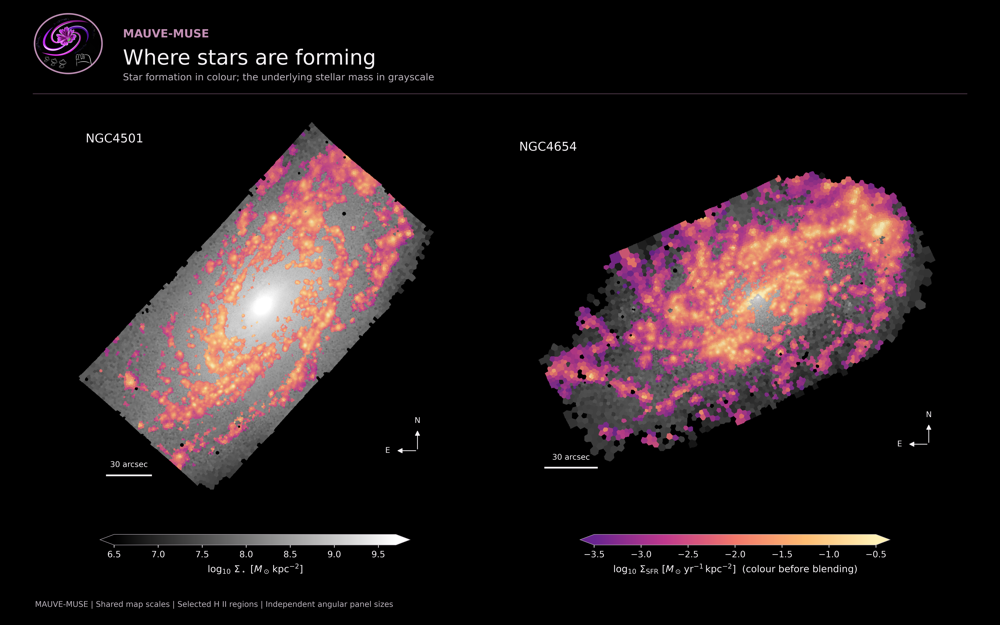

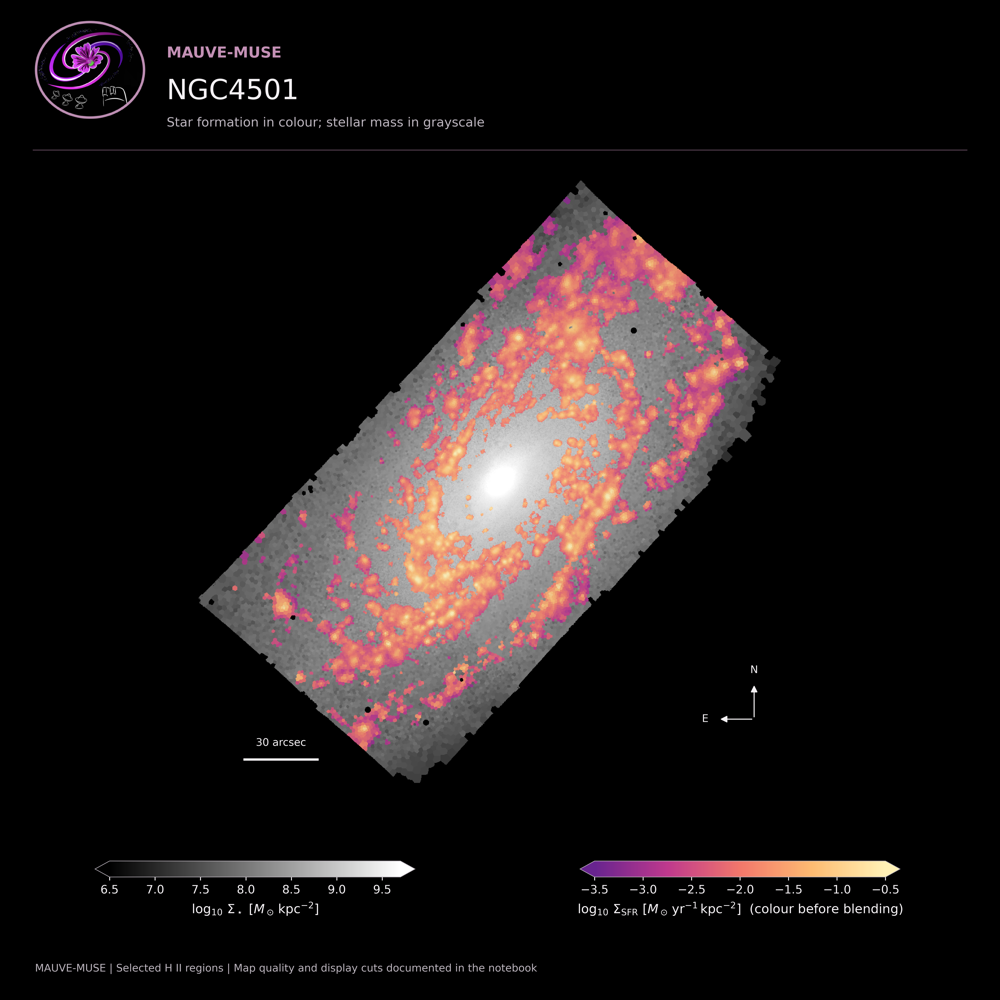

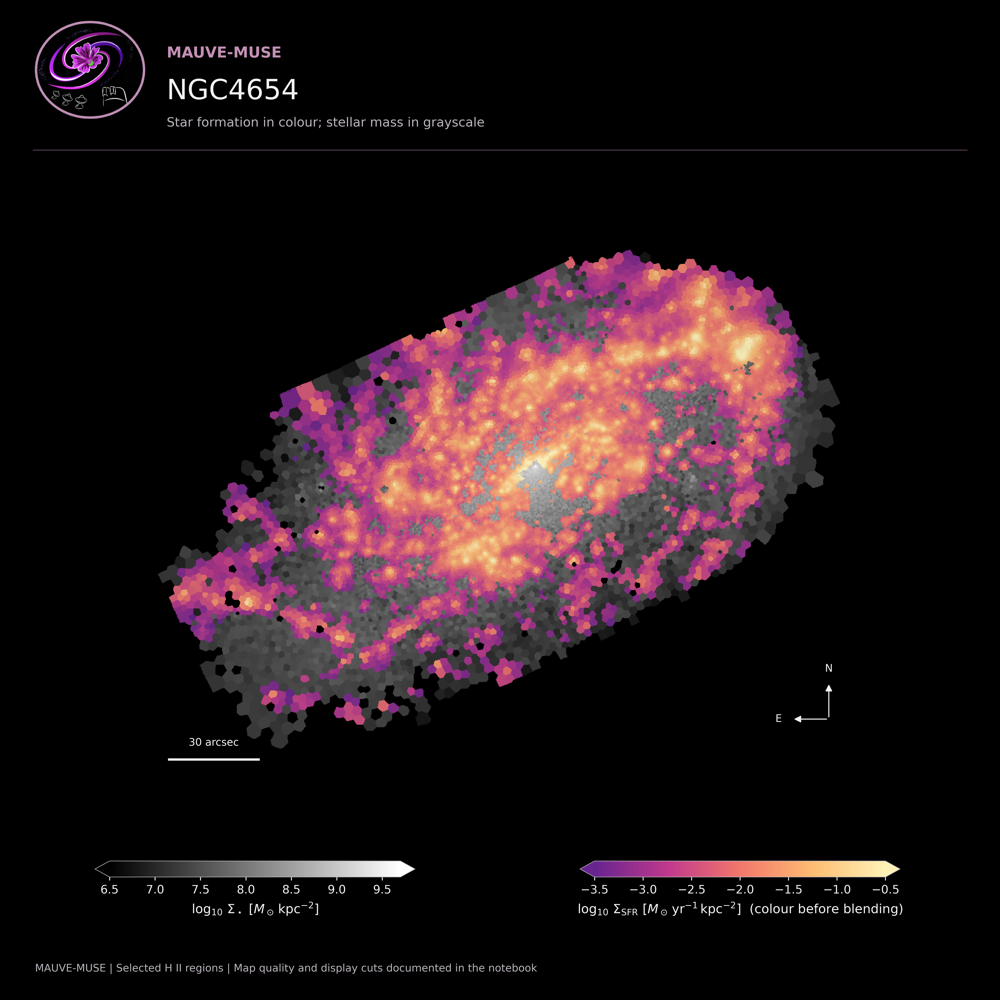

In [6]:
def map_axis(fig, rect, maps, mode='overlay', title=None, annotate=True):
    ax = fig.add_axes(rect)
    mass = np.ma.masked_where(~maps['valid'], maps['mass'])
    sfr = np.ma.masked_where(~maps['sf'], maps['sfr'])
    if mode in ('mass', 'overlay'):
        ax.imshow(mass, origin='lower', cmap='gray', norm=MASS_NORM, interpolation='nearest')
    if mode in ('sfr', 'overlay'):
        ax.imshow(sfr, origin='lower', cmap=SFR_CMAP, norm=SFR_NORM, interpolation='nearest',
                  alpha=SFR_ALPHA if mode == 'overlay' else 1.0)
    ny, nx = maps['shape']
    ax.set(xlim=(-.5, nx-.5), ylim=(-.5, ny-.5), aspect='equal')
    ax.set_axis_off()
    if title:
        ax.text(.02, .97, title, transform=ax.transAxes, fontsize=14, va='top',
                bbox={'facecolor': BG, 'alpha': .7, 'pad': 3, 'edgecolor': 'none'})
    if annotate:
        length = 30 / maps['scale']
        x, y = .075*nx, .065*ny
        ax.plot([x, x+length], [y, y], color=FG, lw=2, solid_capstyle='butt')
        ax.text(x+length/2, y+.022*ny, '30 arcsec', color=FG, fontsize=9, ha='center')
        anchor = np.array([.92*nx, .13*ny])
        for direction, vector in [('N', maps['north_xy']), ('E', maps['east_xy'])]:
            delta = vector / np.linalg.norm(vector) * min(nx, ny)*.06
            end = anchor + delta
            ax.annotate('', xy=end, xytext=anchor, arrowprops={'arrowstyle': '-|>', 'lw': .9, 'color': FG})
            ax.text(*(anchor + 1.35*delta), direction, ha='center', va='center', fontsize=9)
    return ax

def color_key(fig, rect, quantity='sfr', overlay=False):
    cax = fig.add_axes(rect)
    if quantity == 'sfr':
        mappable = mpl.cm.ScalarMappable(norm=SFR_NORM, cmap=SFR_CMAP)
        text = r'$\log_{10}\,\Sigma_{\rm SFR}\ [M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}]$'
    else:
        mappable = mpl.cm.ScalarMappable(norm=MASS_NORM, cmap='gray')
        text = r'$\log_{10}\,\Sigma_\star\ [M_\odot\,\mathrm{kpc}^{-2}]$'
    cb = fig.colorbar(mappable, cax=cax, orientation='horizontal', extend='both')
    cb.set_label(text + ('  (colour before blending)' if overlay else ''), fontsize=11, labelpad=5)
    cb.ax.tick_params(labelsize=10, length=3)
    cb.outline.set_linewidth(.5)

fig = plt.figure(figsize=(16, 10))
branding(fig, 'Where stars are forming', 'Star formation in colour; the underlying stellar mass in grayscale',
         'MAUVE-MUSE | Shared map scales | Selected H II regions | Independent angular panel sizes')
for g, x in zip(HERO_GALAXIES, [.035, .51]):
    map_axis(fig, [x, .20, .455, .605], science[g], title=label(g))
color_key(fig, [.10, .128, .31, .017], 'mass')
color_key(fig, [.58, .128, .31, .017], 'sfr', overlay=True)
save_figure(fig, '03_SFR_on_stellar_mass_pair', 'Star formation over stellar mass: NGC4501 and NGC4654',
            HERO_GALAXIES, pdf=True)

for g in HERO_GALAXIES:
    fig = plt.figure(figsize=(12, 12))
    branding(fig, label(g), 'Star formation in colour; stellar mass in grayscale',
             'MAUVE-MUSE | Selected H II regions | Map quality and display cuts documented in the notebook')
    map_axis(fig, [.045, .20, .91, .62], science[g])
    color_key(fig, [.095, .123, .32, .016], 'mass')
    color_key(fig, [.58, .123, .32, .016], 'sfr', overlay=True)
    save_figure(fig, f'03_{g}_SFR_on_stellar_mass', f'{g}: SFR over stellar mass', [g])

## Additional useful images

The first bonus places the RGB portrait, stellar mass, and **unblended** SFR map together for each galaxy.
It can serve as a talk slide and makes the meaning of the overlay easier to see. The fixed surface-density scales
match Option 3. The RGB footprint includes light outside the science-quality selection, so differences in map extent
must not be interpreted as the disappearance of the galaxy.

The second bonus uses NGC4501 as the large RGB image with four MAUVE thumbnails, as suggested in the source chat.
It combines a recognisable individual galaxy with survey breadth without the density of the full mosaic.

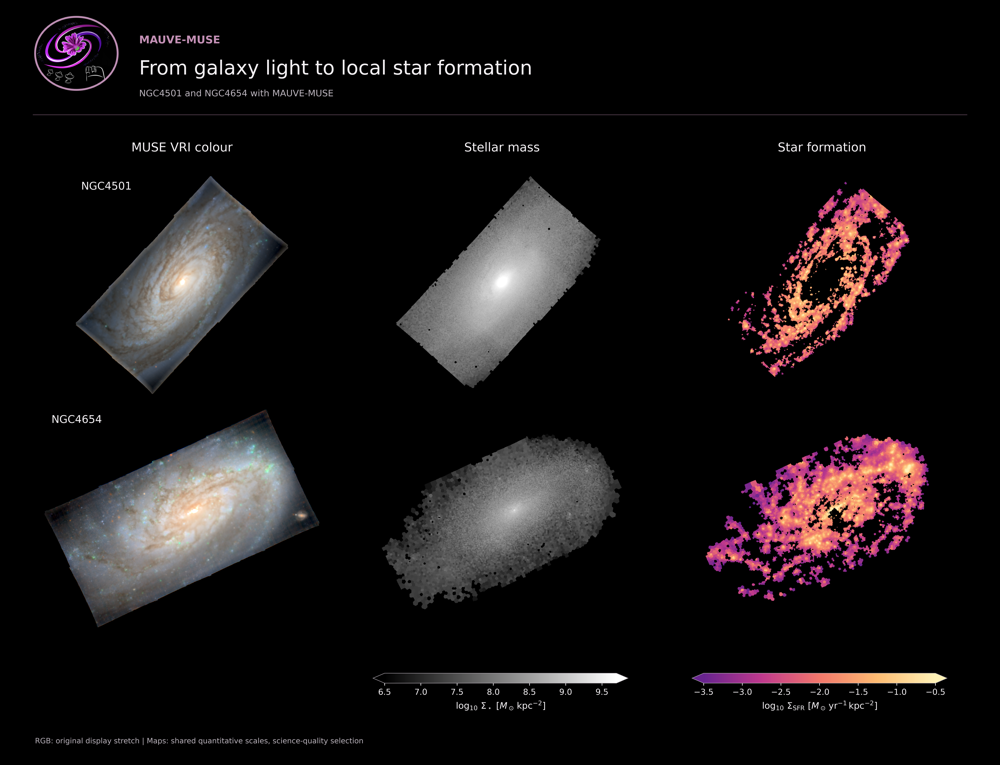

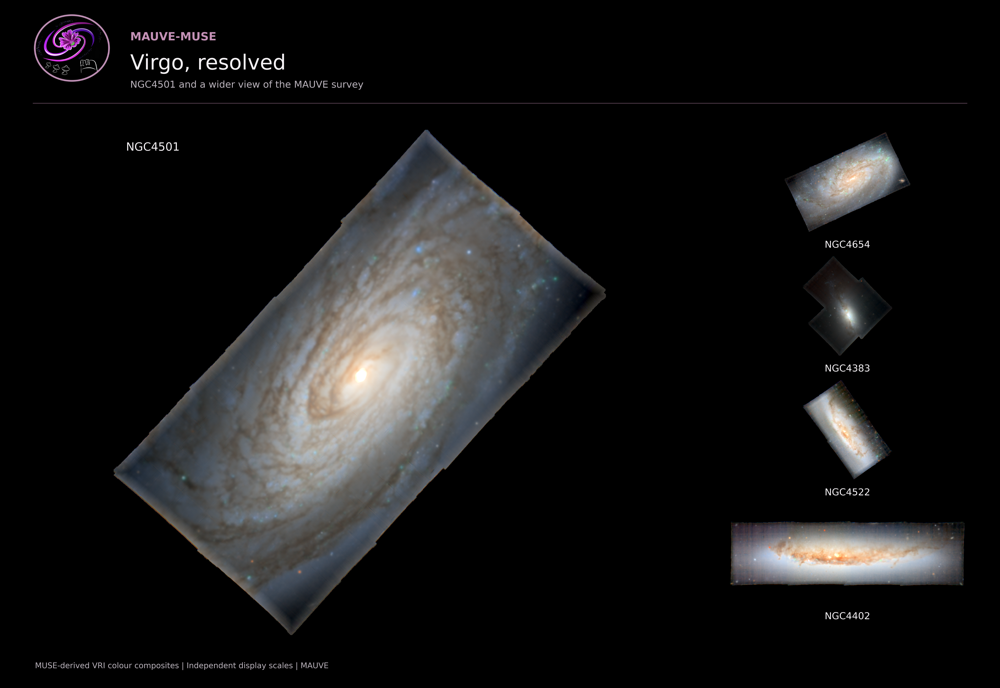

In [7]:
fig = plt.figure(figsize=(17, 13))
branding(fig, 'From galaxy light to local star formation', 'NGC4501 and NGC4654 with MAUVE-MUSE',
         'RGB: original display stretch | Maps: shared quantitative scales, science-quality selection')
for row, g in enumerate(HERO_GALAXIES):
    y = .485 if row == 0 else .18
    image_axis(fig, [.033, y, .298, .285], load_rgb(g), title=g)
    map_axis(fig, [.353, y, .298, .285], science[g], mode='mass', annotate=False)
    map_axis(fig, [.673, y, .298, .285], science[g], mode='sfr', annotate=False)
for x, title in zip([.182, .502, .822], ['MUSE VRI colour', 'Stellar mass', 'Star formation']):
    fig.text(x, .802, title, ha='center', fontsize=15, color=FG)
color_key(fig, [.373, .107, .255, .013], 'mass')
color_key(fig, [.692, .107, .255, .013], 'sfr')
save_figure(fig, '04_RGB_mass_SFR_comparison', 'RGB, stellar mass, and unblended SFR maps', HERO_GALAXIES)

thumbnails = ['NGC4654', 'NGC4383', 'NGC4522', 'NGC4402']
fig = plt.figure(figsize=(16, 11))
branding(fig, 'Virgo, resolved', 'NGC4501 and a wider view of the MAUVE survey',
         'MUSE-derived VRI colour composites | Independent display scales | MAUVE')
image_axis(fig, [.03, .077, .66, .735], load_rgb('NGC4501'), title='NGC4501')
for k, g in enumerate(thumbnails):
    y = .628 - k*.18
    image_axis(fig, [.73, y+.035, .235, .145], load_rgb(g))
    fig.text(.8475, y+.012, g, ha='center', fontsize=11)
save_figure(fig, '05_NGC4501_with_survey_thumbnails', 'NGC4501 RGB hero with four survey thumbnails',
            ['NGC4501']+thumbnails)

## Export overview, provenance, and checks

For a broad Yonsei announcement, start with the **curated mosaic**. The **NGC4501 portrait** is the simplest
individual image. The **paired SFR/mass overlay** emphasizes resolved physics, and the hybrid RGB montage is a
useful fourth candidate. These are communication figures, not statistical results about environment or stripping.

The checks below verify every export, selected map inputs, and unchanged source size/modification times.
`provenance.json` records input paths, image hashes, loaded map-array/header hashes, configuration, and output names.
The large multi-HDU FITS files are not hashed in full; the hashes cover only the HDUs actually read, together with
the source file size and modification time. Scientific calibration pipelines are not rerun or independently validated.

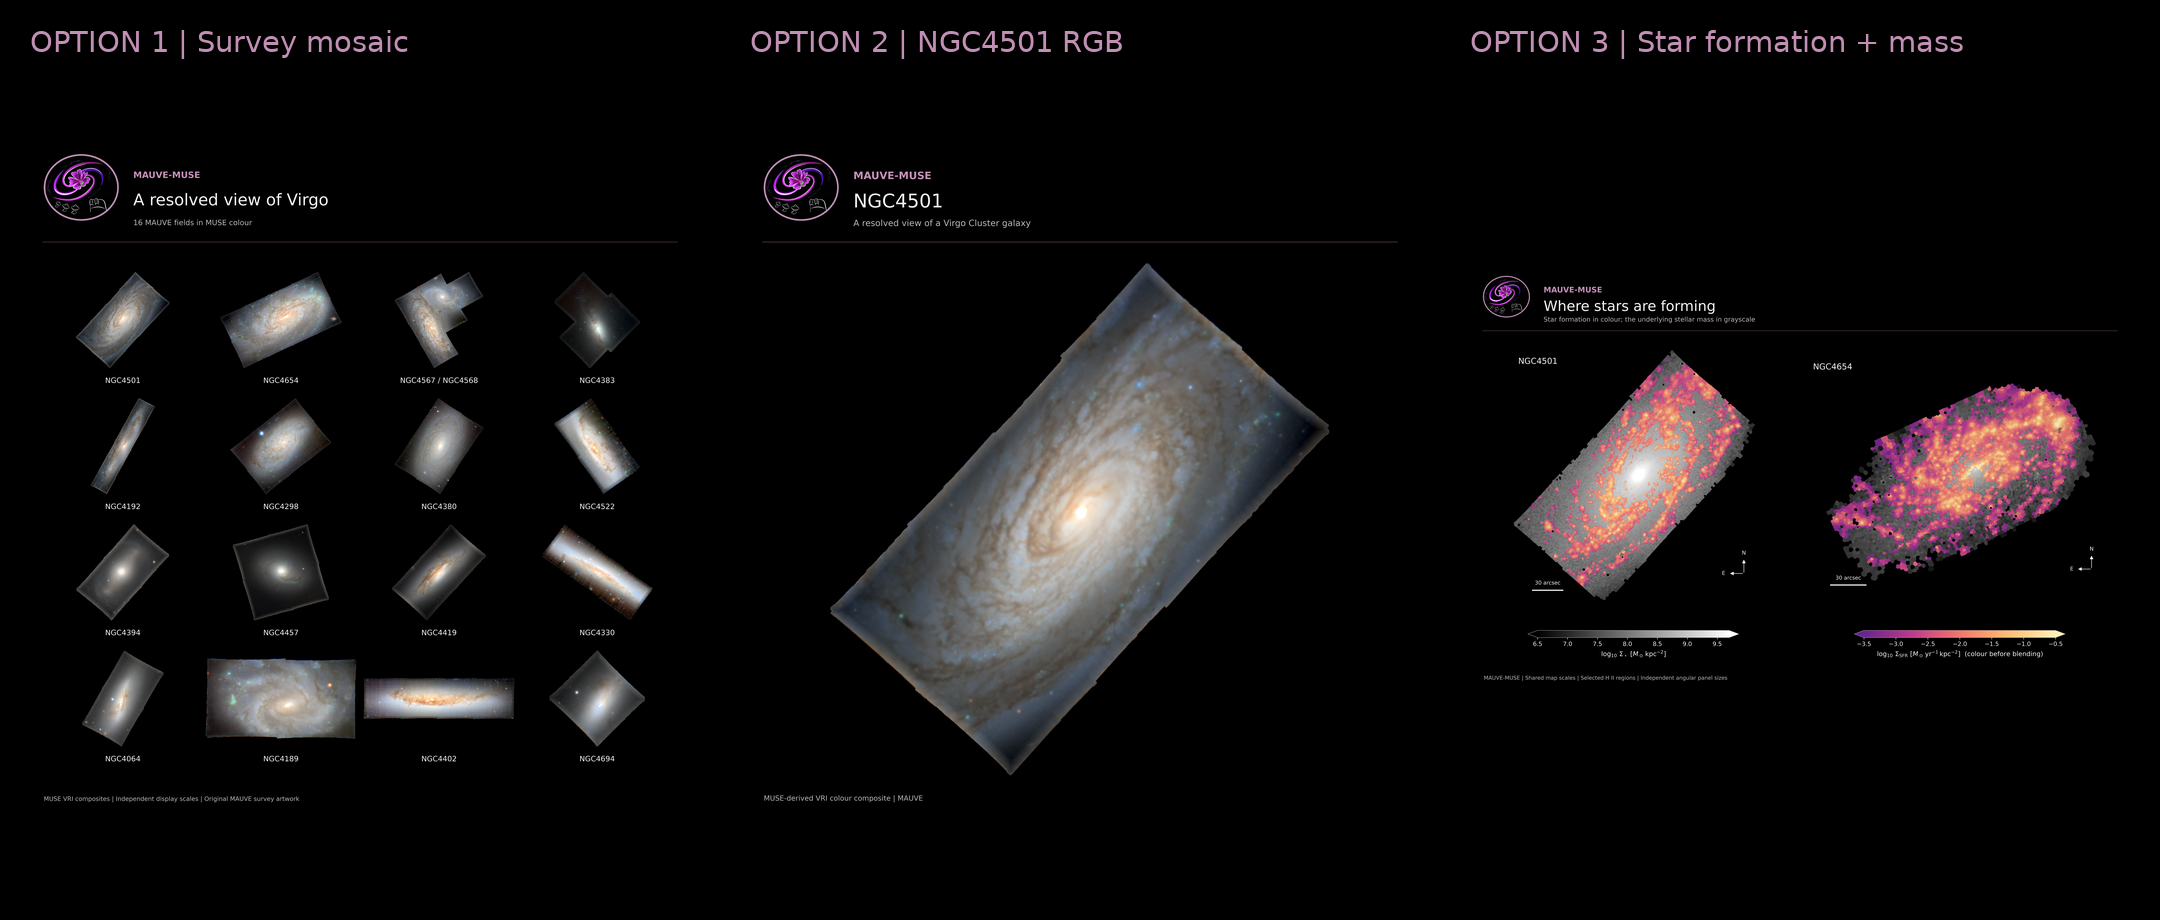

/opt/miniconda3/envs/ICRAR/lib/python3.13/site-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (90720000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


,stem,description,pixels
0,01_mosaic_curated,MAUVE RGB mosaic,"[8400, 8400]"
1,01_mosaic_all_local_fields,MAUVE RGB mosaic,"[8400, 10800]"
2,01_mosaic_9fields_equal_area,"MAUVE RGB mosaic (compact layout, equal panel ...","[8400, 8400]"
3,01_mosaic_9fields_real_size,"MAUVE RGB mosaic (compact layout, uniform phys...","[8400, 8400]"
4,02_NGC4501_RGB,NGC4501: MUSE RGB poster image,"[7200, 7200]"
5,02_NGC4654_RGB,NGC4654: MUSE RGB poster image,"[7200, 7200]"
6,02_RGB_pair,NGC4501 and NGC4654: paired MUSE RGB images,"[9600, 6000]"
7,03_SFR_on_stellar_mass_pair,Star formation over stellar mass: NGC4501 and ...,"[9600, 6000]"
8,03_NGC4501_SFR_on_stellar_mass,NGC4501: SFR over stellar mass,"[7200, 7200]"
9,03_NGC4654_SFR_on_stellar_mass,NGC4654: SFR over stellar mass,"[7200, 7200]"


EXPORT_CHECKS_PASS: 12 poster figures; 5 PDFs; source metadata unchanged.


In [8]:
# Make a compact, labelled comparison without resizing any master exports.
choices = [
    ('01_mosaic_curated', 'OPTION 1 | Survey mosaic'),
    ('02_NGC4501_RGB', 'OPTION 2 | NGC4501 RGB'),
    ('03_SFR_on_stellar_mass_pair', 'OPTION 3 | Star formation + mass'),
]
overview = PILImage.new('RGB', (2160, 920), 'black')
draw = ImageDraw.Draw(overview)
font_path = mpl.font_manager.findfont('DejaVu Sans')
font = ImageFont.truetype(font_path, 29)
for k, (stem, title) in enumerate(choices):
    with PILImage.open(OUT / f'{stem}.png') as im:
        tile = ImageOps.contain(im.convert('RGB'), (680, 810), method=PILImage.Resampling.LANCZOS)
        overview.paste(tile, (k*720+(720-tile.width)//2, 75+(810-tile.height)//2))
    draw.text((k*720+30, 25), title, fill=ACCENT, font=font)
overview.save(OUT / '00_options_overview.png')
display(DisplayImage(filename=str(OUT / '00_options_overview.png'), width=1200))

# Snapshot source code provenance without embedding the large old notebook outputs.
reference = PROJECT_ROOT / '20260904_check_combined_SF_fraction_categories_by_stage_SNR_postfit.ipynb'
reference_nb = json.loads(reference.read_text())
reference_sources = '\n\n'.join(''.join(c.get('source', [])) for c in reference_nb['cells'])
source_record(reference)
SOURCE_RECORDS[str(reference)]['cell_sources_sha256'] = hashlib.sha256(reference_sources.encode()).hexdigest()
for p in [PROJECT_ROOT/'Mass.py', PROJECT_ROOT/'SFR+Z.py', VRI_ROOT/'README.md',
          VRI_ROOT/'v3tk_observed_VRI_image.py']:
    source_record(p, full_hash=True)

for record in SOURCE_RECORDS.values():
    st = Path(record['path']).stat()
    assert (st.st_size, st.st_mtime_ns) == (record['bytes'], record['mtime_ns']), record['path']
for product in PRODUCTS:
    for name in product['files']:
        p = OUT / name
        assert p.exists() and p.stat().st_size > 1000, name
        if p.suffix == '.png':
            with PILImage.open(p) as im:
                im.verify()
        else:
            assert p.read_bytes().startswith(b'%PDF-')
assert len([f for p in PRODUCTS for f in p['files'] if f.endswith('.pdf')]) == 5
provenance = {
    'date': '2026-09-07',
    'source_chat': 'https://chatgpt.com/c/6a9d3c52-9460-83ec-be1d-7023ec6a0ae4',
    'python': platform.python_version(), 'matplotlib': mpl.__version__,
    'config': {'RGB_KIND': RGB_KIND, 'CURATED_GALAXIES': CURATED_GALAXIES, 'STAGE_9_GALAXIES': STAGE_9_GALAXIES,
               'HERO_GALAXIES': HERO_GALAXIES, 'SAVE_DPI': SAVE_DPI,
               'EW_HA_MIN': EW_HA_MIN, 'HALPHA_SIGMA_MAX': HALPHA_SIGMA_MAX,
               'SFH_SNR_POSTFIT_MIN': SFH_SNR_POSTFIT_MIN,
               'MASS_LIMITS': MASS_LIMITS, 'SFR_LIMITS': SFR_LIMITS,
               'SFR_ALPHA': SFR_ALPHA, 'LOGO_CROP': LOGO_CROP,
               'WCS_TOLERANCE_ARCSEC': WCS_TOLERANCE_ARCSEC},
    'image_fields': available, 'map_qc': MAP_QC,
    'sources': list(SOURCE_RECORDS.values()), 'products': PRODUCTS,
    'checks': {'source_sizes_and_mtimes_unchanged': True, 'PNG_decode_checks': True,
               'map_shape_WCS_selection_checks': True},
}
(OUT / 'provenance.json').write_text(json.dumps(provenance, indent=2) + '\n')
index_lines = ['# MAUVE seminar poster image options - 2026-09-07', '',
               'Generated by `../20260907_MAUVE_seminar_poster_image_options.ipynb`.', '',
               'Start with **01_mosaic_curated.png** for the broad survey seminar.', '',
               '![Compare the three options](00_options_overview.png)', '',
               '| Image | Description | Pixels |', '|---|---|---|']
for p in PRODUCTS:
    links = ' / '.join(f'[{Path(f).suffix[1:].upper()}]({f})' for f in p['files'])
    index_lines.append(f"| {p['stem']} {links} | {p['description']} | {p['pixels'][0]} x {p['pixels'][1]} |")
index_lines += ['', '## Provenance and limits', '',
    '- RGBs reuse the original MUSE-derived VRI renderings, with their original stretches and edge processing.',
    '- Curated mosaic: 16 fields, omitting the three PHANGS exemplars. Full inventory: 35 fields / 36 named components.',
    '- Logo: crop of the existing MAUVE banner, with its artwork unchanged.',
    '- Maps: unmasked, finite mass/bins, SFH post-fit S/N > 25; H II SFR, EW(Halpha) > 6 A, and intrinsic sigma < 45 km/s.',
    '- Stored H II selection is retained; separate strict BPT class maps are not imposed as an extra cut.',
    '- Both galaxies share fixed map colour scales. Constant 90% SFR alpha is visual blending, not uncertainty.',
    '- Gray/absent regions do not prove zero SF. No stripping direction or environmental inference is encoded.',
    '- `provenance.json` records exact inputs, selected-HDU hashes, cuts, WCS checks, and output metadata.',
    '- Source products were read only; mass and SFR calibration pipelines were not rerun.', '']
(OUT / 'README.md').write_text('\n'.join(index_lines))
display(pd.DataFrame(PRODUCTS)[['stem', 'description', 'pixels']])
pdf_count = len([f for p in PRODUCTS for f in p['files'] if f.endswith('.pdf')])
print(f'EXPORT_CHECKS_PASS: {len(PRODUCTS)} poster figures; {pdf_count} PDFs; source metadata unchanged.')


## Presentation poster | MAUVE_MUSE_20260907

A resolved view of Virgo spirals: 9-field uniform physical scale poster featuring the full MAUVE survey banner and QR codes for the MAUVE website and presenter.

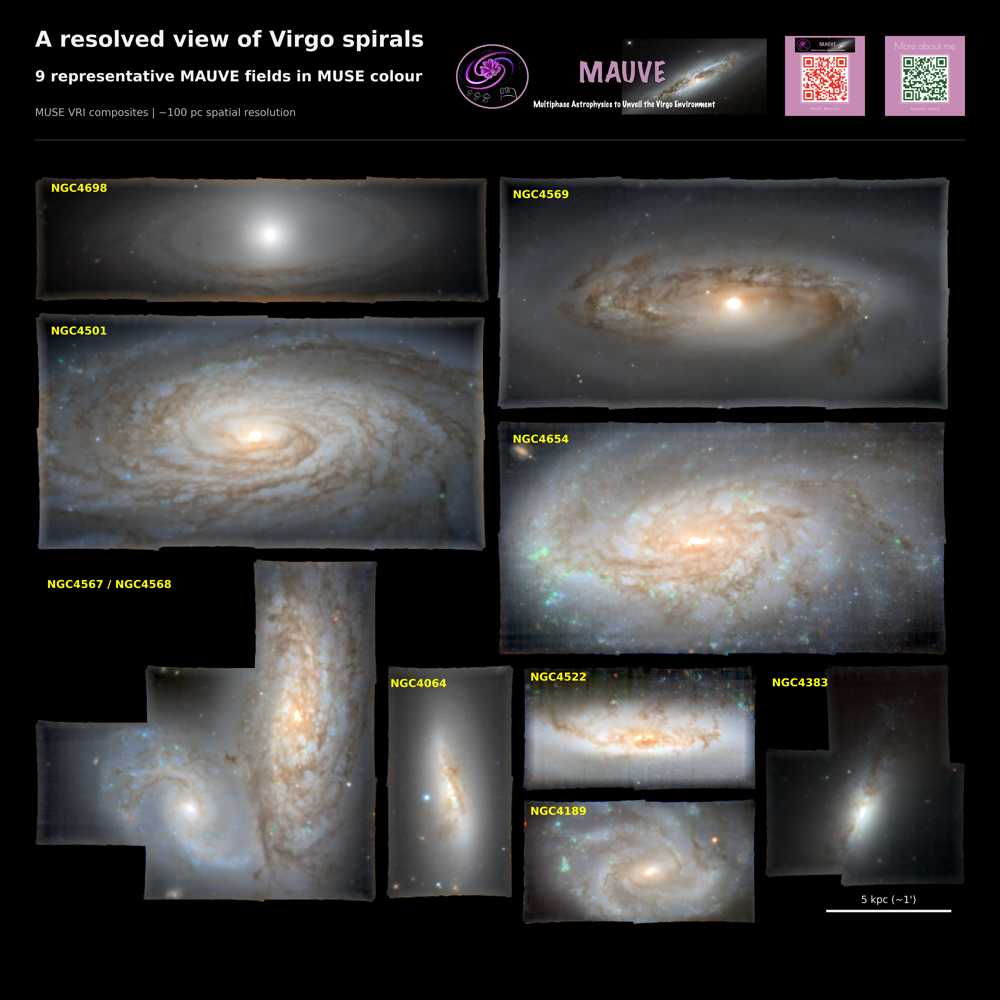

PRESENTATION_POSTER_PASS: MAUVE_MUSE_20260907 generated successfully (13 total products).


In [9]:
# Final presentation poster: A resolved view of Virgo spirals
banner_path = PROJECT_ROOT.parent / 'MAUVE' / 'mauve_newbanner.png'
mauve_qr_path = PROJECT_ROOT.parent / 'EAS2026' / 'MAUVE QR.png'
me_qr_path = PROJECT_ROOT.parent / 'EAS2026' / 'Me QR.png'

banner = PILImage.open(source_record(banner_path, full_hash=True))
mauve_qr = PILImage.open(source_record(mauve_qr_path, full_hash=True))
me_qr = PILImage.open(source_record(me_qr_path, full_hash=True))

def produce_presentation_poster(galaxies, stem='MAUVE_MUSE_20260907', pdf=True):
    crops = {g: align_and_crop(g) for g in galaxies}
    processed_images = {}
    for g in crops:
        im = crops[g][0]
        if g == 'NGC4383': im = im.rotate(270, expand=True)
        elif g == 'NGC4698': im = im.rotate(180, expand=True)
        elif g == 'NGC4567_8': im = im.rotate(90, expand=True)
        elif g == 'NGC4064': im = im.rotate(-90, expand=True)
        elif g == 'NGC4522': pass
        processed_images[g] = im

    gap = 20
    pos = {}
    pos['NGC4698'] = (0, 0)
    pos['NGC4569'] = (processed_images['NGC4698'].width + gap, 0)
    pos['NGC4501'] = (0, processed_images['NGC4698'].height + gap)
    pos['NGC4654'] = (pos['NGC4569'][0], processed_images['NGC4654'].height + gap)
    pos['NGC4567_8'] = (0, pos['NGC4501'][1] + processed_images['NGC4501'].height + gap)
    y_row3 = max(pos['NGC4654'][1] + processed_images['NGC4654'].height + gap, 1240)
    pos['NGC4064'] = (pos['NGC4567_8'][0] + processed_images['NGC4567_8'].width + gap, y_row3)
    pos['NGC4522'] = (pos['NGC4064'][0] + processed_images['NGC4064'].width + gap, y_row3)
    pos['NGC4189'] = (pos['NGC4522'][0], pos['NGC4522'][1] + processed_images['NGC4522'].height + gap)
    x_right = max(pos['NGC4522'][0] + processed_images['NGC4522'].width, pos['NGC4189'][0] + processed_images['NGC4189'].width) + gap
    pos['NGC4383'] = (x_right, y_row3)

    mx = max(pos[g][0] + processed_images[g].width for g in galaxies)
    my = max(pos[g][1] + processed_images[g].height for g in galaxies)
    scale = min(3906 / mx, 3234 / my)

    fig = plt.figure(figsize=(14, 14), facecolor=BG)

    # Title block on left
    fig.text(.035, .970, 'A resolved view of Virgo spirals', fontsize=22, weight='bold', color=FG, va='top')
    fig.text(.035, .930, f'{len(galaxies)} representative MAUVE fields in MUSE colour', fontsize=15, weight='semibold', color=FG, va='top')
    fig.text(.035, .892, 'MUSE VRI composites | ~100 pc spatial resolution', fontsize=10.5, color=MUTED, va='top')

    # Center: Full MAUVE banner
    ax_b = fig.add_axes([.448, .884, .320, .320 / 4.071])
    ax_b.imshow(banner)
    ax_b.set_axis_off()

    # Top right: MAUVE & Rongjun Huang QR codes
    ax_qr1 = fig.add_axes([.785, .884, .080, .080])
    ax_qr1.imshow(mauve_qr)
    ax_qr1.set_axis_off()

    ax_qr2 = fig.add_axes([.885, .884, .080, .080])
    ax_qr2.imshow(me_qr)
    ax_qr2.set_axis_off()

    # Separator accent line
    fig.add_artist(Line2D([.035, .965], [.860, .860], transform=fig.transFigure, color='#333333', linewidth=1.0))

    # Galaxy axes
    left_base = 0.035 + (3906 - mx * scale) / (2 * 4200.0)
    top_base = 0.835 - (3234 - my * scale) / (2 * 4200.0)

    for g in galaxies:
        x_px, y_px = pos[g]
        im_crop = processed_images[g]
        w_norm = (im_crop.width * scale) / 4200.0
        h_norm = (im_crop.height * scale) / 4200.0
        x_norm = left_base + (x_px * scale) / 4200.0
        y_norm = top_base - ((y_px + im_crop.height) * scale) / 4200.0

        ax = fig.add_axes([x_norm, y_norm, w_norm, h_norm])
        ax.imshow(im_crop, origin='upper', aspect='equal')
        ax.set_axis_off()
        ax.text(.035, .94, label(g), transform=ax.transAxes, va='top', ha='left',
                fontsize=11, weight='bold', color='yellow')

    # Scale bar
    kpc_5_norm = (5000.0 / 16.0 * scale) / 4200.0
    bar_x = 0.965 - kpc_5_norm - 0.015
    bar_y = 0.075 + 0.014
    fig.add_artist(Line2D([bar_x, bar_x + kpc_5_norm], [bar_y, bar_y],
                          transform=fig.transFigure, color=FG, linewidth=2.5))
    fig.text(bar_x + kpc_5_norm/2, bar_y + 0.006, "5 kpc (~1')",
             ha='center', va='bottom', fontsize=10, color=FG)

    save_figure(fig, stem, 'A resolved view of Virgo spirals (MAUVE presentation poster)', galaxies, pdf=pdf)

produce_presentation_poster(STAGE_9_GALAXIES, 'MAUVE_MUSE_20260907', pdf=True)

# Update provenance.json and README.md with the presentation poster
provenance_path = OUT / 'provenance.json'
if provenance_path.exists():
    prov = json.loads(provenance_path.read_text())
    prov['products'] = PRODUCTS
    provenance_path.write_text(json.dumps(prov, indent=2) + '\n')

readme_path = OUT / 'README.md'
index_lines = ['# MAUVE seminar poster image options - 2026-09-07', '',
               'Generated by `../20260907_MAUVE_seminar_poster_image_options.ipynb`.', '',
               'Start with **MAUVE_MUSE_20260907.png** for the final presentation poster, or **01_mosaic_curated.png** for the broad survey seminar.', '',
               '![Compare the three options](00_options_overview.png)', '',
               '| Image | Description | Pixels |', '|---|---|---|']
for p in PRODUCTS:
    links = ' / '.join(f'[{Path(f).suffix[1:].upper()}]({f})' for f in p['files'])
    index_lines.append(f"| {p['stem']} {links} | {p['description']} | {p['pixels'][0]} x {p['pixels'][1]} |")
index_lines += ['', '## Provenance and limits', '',
    '- RGBs reuse the original MUSE-derived VRI renderings, with their original stretches and edge processing.',
    '- Curated mosaic: 16 fields, omitting the three PHANGS exemplars. Full inventory: 35 fields / 36 named components.',
    '- Logo: crop of the existing MAUVE banner, with its artwork unchanged.',
    '- Presentation poster includes full MAUVE survey banner and QR codes for project website and presenter.',
    '- Maps: unmasked, finite mass/bins, SFH post-fit S/N > 25; H II SFR, EW(Halpha) > 6 A, and intrinsic sigma < 45 km/s.',
    '- Stored H II selection is retained; separate strict BPT class maps are not imposed as an extra cut.',
    '- Both galaxies share fixed map colour scales. Constant 90% SFR alpha is visual blending, not uncertainty.',
    '- Gray/absent regions do not prove zero SF. No stripping direction or environmental inference is encoded.',
    '- `provenance.json` records exact inputs, selected-HDU hashes, cuts, WCS checks, and output metadata.',
    '- Source products were read only; mass and SFR calibration pipelines were not rerun.', '']
readme_path.write_text('\n'.join(index_lines) + '\n')

print(f'PRESENTATION_POSTER_PASS: MAUVE_MUSE_20260907 generated successfully ({len(PRODUCTS)} total products).')
